<a href="https://colab.research.google.com/github/estemartinez87-cell/ENTREGA-FINAL-DATA-SCIENCE-II/blob/main/proyecto_final_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final de Machine Learning
## Predicción de riesgo epidemiológico en Argentina a partir de cobertura de vacunación y contexto socioeconómico



## 1. Formulación del problema

Entre 2015 y 2021, Argentina vivió algo que pocos países lograron sostener: casi una década con las coberturas de vacunación infantil por encima del 85%, un escudo silencioso que mantuvo a raya enfermedades que el país ya daba por superadas. El sarampión estaba eliminado desde 2016. La tos convulsa aparecía en cifras manejables. Nadie hablaba de polio porque, sencillamente, no había motivo.
Ese equilibrio se quebró. La pandemia interrumpió los calendarios de vacunación, pero lo que vino después no fue una recuperación sino una caída sostenida: para 2024, la segunda dosis de triple viral había pasado del 90% al 46%, y la cobertura antipoliomielítica se desplomó de manera similar. Casi en simultáneo, el país empezó a ver algo que no veía en años: brotes de sarampión, una cifra récord de casos de coqueluche, y advertencias activas de la OPS por riesgo de reintroducción de polio.
La pregunta que motiva este trabajo es si esa secuencia (primero cae la cobertura, después aparece la enfermedad) es una coincidencia temporal o un patrón que se puede anticipar. La hipótesis central es que el deterioro de la cobertura de vacunación de un año funciona como una señal de alerta temprana, medible y predictiva, del riesgo de reaparición de enfermedades prevenibles al año siguiente, y que ese riesgo se intensifica cuando el deterioro sanitario coincide con un deterioro socioeconómico (más pobreza, más desempleo, más inflación erosionando el acceso a los centros de salud).
Si la hipótesis es correcta, debería ser posible entrenar un modelo que, mirando únicamente la cobertura de vacunación del año anterior y el contexto socioeconómico del momento, distinga con una precisión mejor que el azar los años en que Argentina entra en una zona de riesgo epidemiológico alto. Y si ese patrón existe con la fuerza suficiente, tiene una implicancia que va más allá de lo estadístico: significa que la próxima crisis sanitaria no llega sin avisar, llega con un año de anticipación escrita en los datos de cobertura, y la pregunta deja de ser si se puede prever, sino si alguien está mirando esos datos a tiempo para actuar.

Esa es, en esencia, la hipótesis que el modelo de clasificación de este proyecto pone a prueba: que la vacunación no es solo una medida preventiva individual, sino un indicador adelantado del riesgo colectivo que viene.


**Contexto de negocio / decisión:** Argentina registró en 2024-2025 una caída histórica
en las coberturas de vacunación (triple viral, antipolio) y un repunte simultáneo de
enfermedades prevenibles por vacunas (coqueluche, sarampión). Un organismo de salud
pública necesita **anticipar qué años presentan alto riesgo epidemiológico** para poder
priorizar campañas de vacunación y asignar recursos de vigilancia epidemiológica.

**Tarea:** Clasificación binaria supervisada.

**Variable objetivo (target):** `riesgo_alto`
- `1` = año de "alerta epidemiológica" (hubo casos de sarampión confirmados **o** los
  casos de coqueluche superaron el percentil 75 histórico)
- `0` = año sin alerta relevante

**Variables predictoras:** cobertura de vacunación del año anterior (para evitar fuga de
información/causalidad inversa), indicadores socioeconómicos del año en curso y una
variable de tendencia temporal.

**Métrica de éxito principal:** AUC-ROC (apropiada para clasificación binaria con clases
desbalanceadas, ya que no asume un umbral de decisión fijo).
Métricas secundarias: Accuracy, F1-score, matriz de confusión.

**Relevancia para la decisión:** un modelo con buen AUC permitiría priorizar, en años
de cobertura decreciente y deterioro socioeconómico, el refuerzo de campañas de
vacunación **antes** de que se confirme un brote.

**Limitación explícita:** el dataset tiene resolución anual (2000-2025, n=26), por lo
que se trata de un ejercicio académico/exploratorio. Se usan técnicas apropiadas para
muestras pequeñas (Leave-One-Out Cross-Validation) y los resultados deben interpretarse
con cautela, no como un sistema de predicción operativo.

## 2. Carga de datos

**Fuentes de los datos** (ver `README.md` para el detalle completo):
- INDEC (pobreza, indigencia, desempleo, inflación, tipo de cambio)
- DEIS / Ministerio de Salud (mortalidad infantil, esperanza de vida, fecundidad adolescente)
- SAP / Boletín Epidemiológico Nacional / OPS (casos de coqueluche y sarampión)
- Nomivac / SAP (coberturas de vacunación)

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("https://raw.githubusercontent.com/estemartinez87-cell/ENTREGA-FINAL-DATA-SCIENCE-II/main/argentina_dataset.csv")
df = df.set_index("anio")
print(f"Dimensiones: {df.shape[0]} filas (años) x {df.shape[1]} columnas")
df.head()

Dimensiones: 26 filas (años) x 13 columnas


,mortalidad_infantil,esperanza_vida,cobertura_tv1,cobertura_tv2,cobertura_polio,coqueluche_casos,sarampion_casos,pobreza,indigencia,desempleo,inflacion_anual,tipo_cambio,fecundidad_adolescente
anio,,,,,,,,,,,,,
2000,16.6,73.6,85,80.0,82.0,1200,15,45.4,20.8,15.1,-0.9,0.999,63.4
2001,16.3,74.0,87,82.0,84.0,1400,8,38.3,15.4,18.3,-1.1,0.999,61.2
2002,16.1,74.2,88,84.0,85.0,1800,12,53.0,24.8,21.5,41.0,3.360,59.8
2003,15.9,74.5,89,85.0,86.0,2500,5,47.8,20.5,17.3,3.7,2.950,58.1
2004,14.9,74.7,90,87.0,87.0,3100,3,40.2,15.7,13.6,4.4,2.960,55.7


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Valores faltantes y tipos de datos

In [ ]:
info = pd.DataFrame({
    "dtype": df.dtypes,
    "n_faltantes": df.isna().sum(),
    "% faltantes": (df.isna().mean() * 100).round(2),
})
info

,dtype,n_faltantes,% faltantes
mortalidad_infantil,float64,0,0.0
esperanza_vida,float64,0,0.0
cobertura_tv1,int64,0,0.0
cobertura_tv2,float64,0,0.0
cobertura_polio,float64,0,0.0
coqueluche_casos,int64,0,0.0
sarampion_casos,int64,0,0.0
pobreza,float64,0,0.0
indigencia,float64,0,0.0
desempleo,float64,0,0.0


No hay valores faltantes en el dataset original (se introducirán por diseño al
crear variables rezagadas/lag en la sección de feature engineering).

### 3.2 Estadísticos descriptivos: media, mediana, dispersión, forma de la distribución

In [ ]:
def estadisticos_avanzados(serie: pd.Series) -> dict:
    """Media, mediana, dispersión, outliers (IQR/Tukey), curtosis y asimetría."""
    s = serie.dropna()
    p25, p50, p75 = np.percentile(s, [25, 50, 75])
    iqr = p75 - p25
    fence_lo, fence_hi = p25 - 1.5 * iqr, p75 + 1.5 * iqr
    outliers = s[(s < fence_lo) | (s > fence_hi)]
    kurt = float(stats.kurtosis(s, fisher=True))
    skew = float(stats.skew(s))
    return {
        "media": s.mean(), "mediana": p50, "std": s.std(),
        "min": s.min(), "max": s.max(), "p25": p25, "p75": p75, "iqr": iqr,
        "fence_lo": fence_lo, "fence_hi": fence_hi,
        "n_outliers": len(outliers), "outliers": outliers.to_dict(),
        "curtosis": round(kurt, 3), "asimetria": round(skew, 3),
    }

resumen = pd.DataFrame({col: estadisticos_avanzados(df[col]) for col in df.columns}).T
resumen[["media","mediana","std","min","max","iqr","n_outliers","curtosis","asimetria"]].round(2)

,media,mediana,std,min,max,iqr,n_outliers,curtosis,asimetria
mortalidad_infantil,11.026923,10.1,2.95656,8.0,16.6,4.375,0,-0.922,0.68
esperanza_vida,75.961538,76.2,1.093646,73.6,77.5,1.55,0,-0.684,-0.618
cobertura_tv1,88.423077,90.0,3.523329,80,92,4.0,1,0.022,-1.075
cobertura_tv2,81.807692,89.0,15.046353,46.0,91.0,5.75,4,1.561,-1.821
cobertura_polio,81.607692,88.0,14.306444,47.6,90.3,4.75,4,1.631,-1.861
coqueluche_casos,1530.846154,1600.0,736.551787,350,3100,965.5,0,-0.561,0.073
sarampion_casos,9.846154,0.0,33.519776,0,170,3.0,5,18.697,4.449
pobreza,33.35,34.65,9.278761,18.5,53.0,13.05,0,-0.809,0.122
indigencia,9.938462,8.15,5.735579,3.7,24.8,4.725,3,0.343,1.198
desempleo,10.046154,8.5,4.021068,5.7,21.5,3.6,3,1.221,1.436


**Lectura rápida:** las variables `inflacion_anual` y `tipo_cambio` muestran curtosis
alta (leptocúrticas) y outliers marcados — coincide con los episodios de crisis
macroeconómica (2002, 2019, 2023). `cobertura_tv2` y `cobertura_polio` muestran un
quiebre estructural a partir de 2022-2023 (outliers por caída abrupta), que es
precisamente la señal que el modelo intentará capturar.

### 3.3 Visualización: distribución y outliers de variables clave

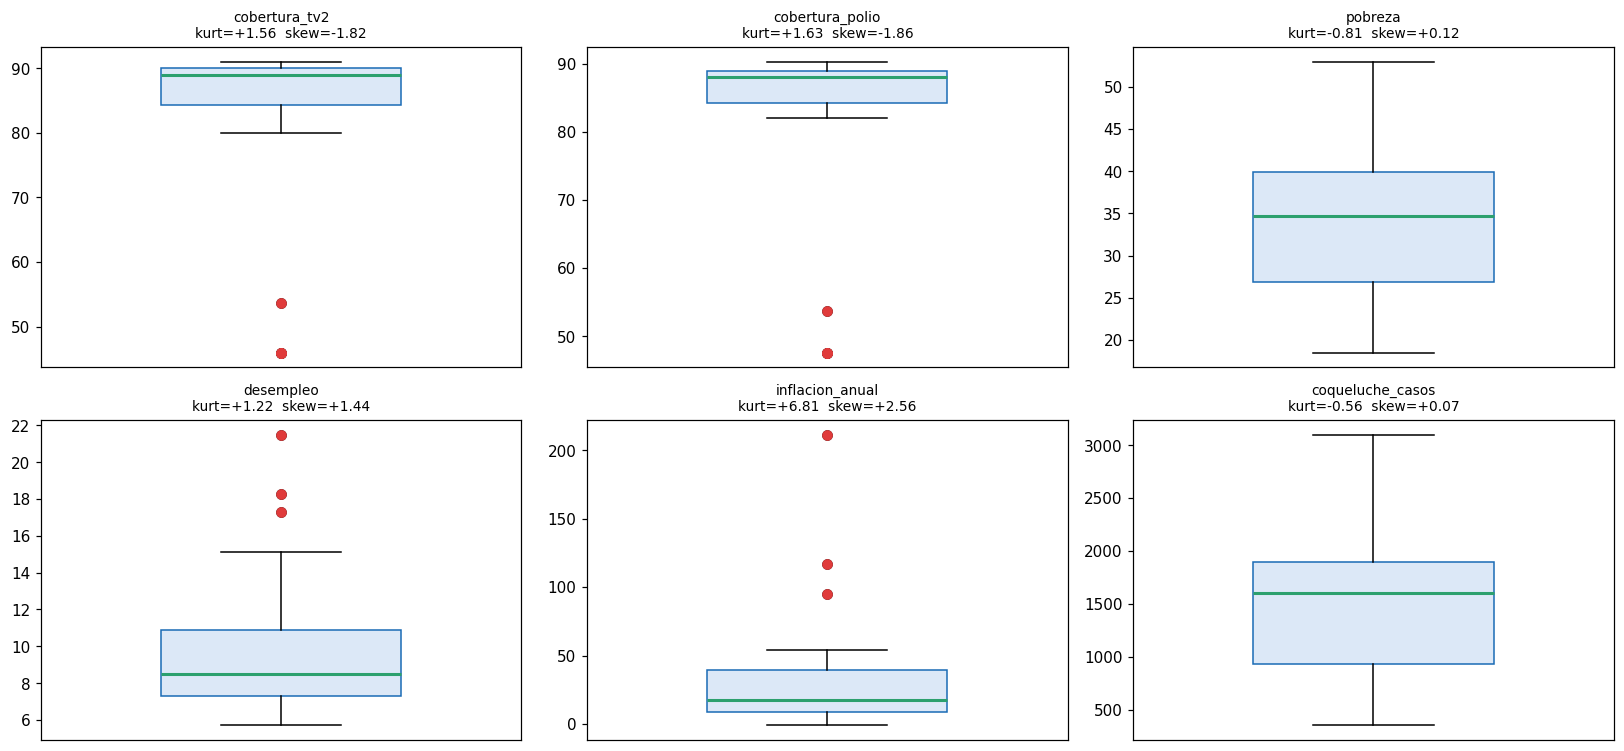

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
cols_eda = ["cobertura_tv2", "cobertura_polio", "pobreza",
            "desempleo", "inflacion_anual", "coqueluche_casos"]

for ax, col in zip(axes.flat, cols_eda):
    st = estadisticos_avanzados(df[col])
    ax.boxplot(df[col].dropna(), vert=True, widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor="#dce8f7", edgecolor="#1a6bb5"),
               medianprops=dict(color="#2ca06e", lw=2))
    ax.scatter([1]*st["n_outliers"], list(st["outliers"].values()),
               color="#e03b3b", zorder=5, label="outliers")
    ax.set_title(f"{col}\nkurt={st['curtosis']:+.2f}  skew={st['asimetria']:+.2f}",
                fontsize=9)
    ax.set_xticks([])
plt.tight_layout()
plt.savefig("../img/eda_boxplots.png", dpi=130, bbox_inches="tight")
plt.show()

### 3.4 Matriz de correlación

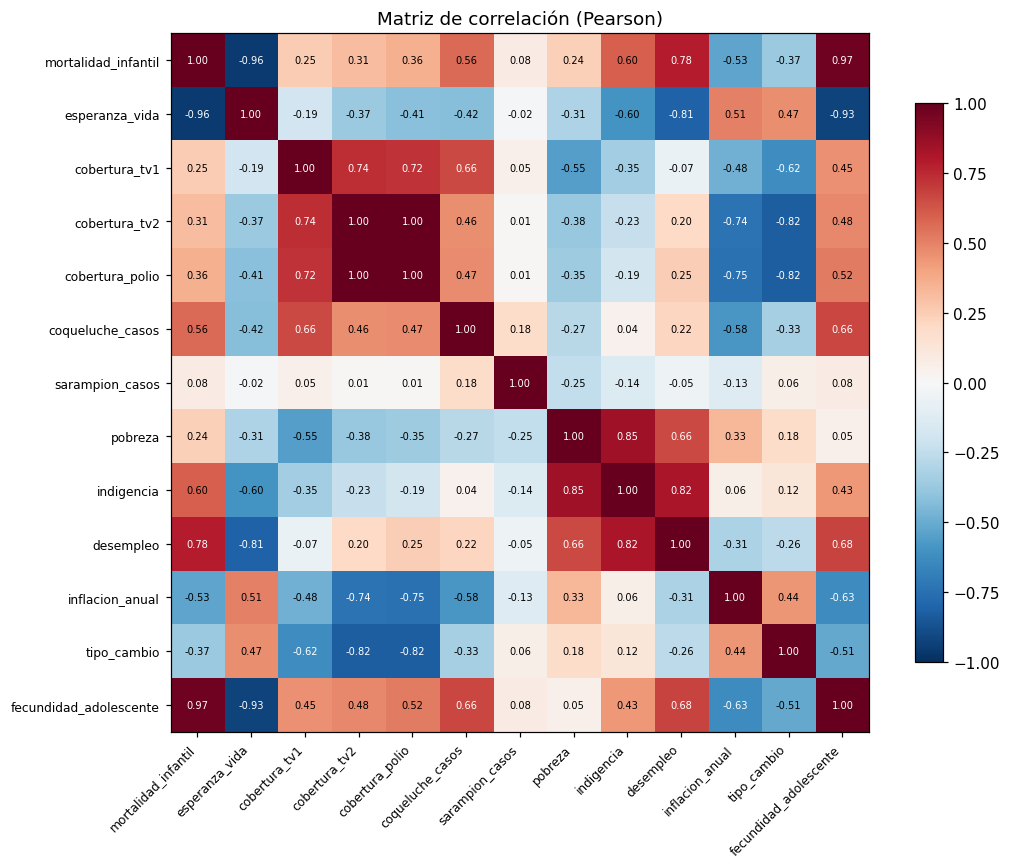

In [ ]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(corr.iloc[i,j]) > 0.6 else "black")
plt.colorbar(im, shrink=0.8)
plt.title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.savefig("../img/correlation_matrix.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Ingeniería de atributos

Decisiones de diseño:
1. **Variables rezagadas (lag):** usamos la cobertura de vacunación del **año anterior**
   como predictora, no la del año actual, para reflejar la relación causal real
   (la caída de cobertura antecede al brote) y evitar fuga de información.
2. **Transformación logarítmica:** `inflacion_anual` y `tipo_cambio` tienen alta
   curtosis/asimetría (ver EDA) — aplicamos `log1p` para estabilizar varianza.
3. **Tendencia temporal normalizada:** `anio_norm` captura el efecto de tendencia
   estructural (deterioro institucional/sanitario) independiente de las demás variables.
4. **Variable objetivo compuesta:** combina dos enfermedades centinela
   (sarampión y coqueluche) en un único indicador de riesgo.

In [ ]:
df_feat = df.copy()

# Lags de cobertura (año t-1)
df_feat["cobertura_tv2_lag1"]   = df_feat["cobertura_tv2"].shift(1)
df_feat["cobertura_polio_lag1"] = df_feat["cobertura_polio"].shift(1)

# Transformación log para variables con alta curtosis/asimetría
df_feat["inflacion_log"] = np.log1p(df_feat["inflacion_anual"].clip(lower=-50) + 50)
df_feat["tipo_cambio_log"] = np.log1p(df_feat["tipo_cambio"])

# Tendencia temporal normalizada [0,1]
df_feat["anio_norm"] = (df_feat.index - df_feat.index.min()) / (df_feat.index.max() - df_feat.index.min())

# Variable objetivo: riesgo epidemiológico alto
p75_coq = df_feat["coqueluche_casos"].quantile(0.75)
df_feat["riesgo_alto"] = (
    (df_feat["sarampion_casos"] > 0) | (df_feat["coqueluche_casos"] > p75_coq)
).astype(int)

print(f"Umbral P75 coqueluche: {p75_coq:.0f} casos")
print(f"\nDistribución de la variable objetivo:")
print(df_feat["riesgo_alto"].value_counts())
print(f"\nProporción de años de alto riesgo: {df_feat['riesgo_alto'].mean():.1%}")

Umbral P75 coqueluche: 1900 casos

Distribución de la variable objetivo:
riesgo_alto
0    14
1    12
Name: count, dtype: int64

Proporción de años de alto riesgo: 46.2%


In [ ]:
FEATURES = [
    "cobertura_tv2_lag1", "cobertura_polio_lag1",
    "pobreza", "desempleo", "inflacion_log", "fecundidad_adolescente", "anio_norm",
]
TARGET = "riesgo_alto"

df_model = df_feat.dropna(subset=FEATURES + [TARGET]).copy()
print(f"Filas disponibles para modelado tras dropna (por el lag): {len(df_model)}")
df_model[FEATURES + [TARGET]].head()

Filas disponibles para modelado tras dropna (por el lag): 25


,cobertura_tv2_lag1,cobertura_polio_lag1,pobreza,desempleo,inflacion_log,fecundidad_adolescente,anio_norm,riesgo_alto
anio,,,,,,,,
2001,80.0,82.0,38.3,18.3,3.910021,61.2,0.04,1
2002,82.0,84.0,53.0,21.5,4.521789,59.8,0.08,1
2003,84.0,85.0,47.8,17.3,4.001864,58.1,0.12,1
2004,85.0,86.0,40.2,13.6,4.014580,55.7,0.16,1
2005,87.0,87.0,33.8,11.6,4.096010,53.2,0.20,1


## 5. Entrenamiento de modelos

Dado el tamaño reducido de la muestra (n≈25), usamos:
- **GridSearchCV con validación cruzada estratificada (5 folds)** para seleccionar
  hiperparámetros.
- **Leave-One-Out Cross-Validation (LOOCV)** para la evaluación final honesta del
  modelo seleccionado (técnica recomendada para datasets pequeños).

Modelos comparados: Regresión Logística (lineal, interpretable), Random Forest
(no lineal, robusto a outliers) y XGBoost (boosting, capta interacciones).

In [3]:
from sklearn.model_selection import (
    StratifiedKFold, LeaveOneOut, GridSearchCV, cross_val_predict
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, RocCurveDisplay
)
from xgboost import XGBClassifier

# Re-defining df_feat, FEATURES, TARGET, and df_model here
# to ensure they are available even if previous cells were not executed.
# Assuming 'df' is available from a prior successful execution.

# --- Start of code from cell 10feddbb ---
df_feat = df.copy()

# Lags de cobertura (año t-1)
df_feat["cobertura_tv2_lag1"]   = df_feat["cobertura_tv2"].shift(1)
df_feat["cobertura_polio_lag1"] = df_feat["cobertura_polio"].shift(1)

# Transformación log para variables con alta curtosis/asimetría
df_feat["inflacion_log"] = np.log1p(df_feat["inflacion_anual"].clip(lower=-50) + 50)
df_feat["tipo_cambio_log"] = np.log1p(df_feat["tipo_cambio"])

# Tendencia temporal normalizada [0,1]
df_feat["anio_norm"] = (df_feat.index - df_feat.index.min()) / (df_feat.index.max() - df_feat.index.min())

# Variable objetivo: riesgo epidemiológico alto
p75_coq = df_feat["coqueluche_casos"].quantile(0.75)
df_feat["riesgo_alto"] = (
    (df_feat["sarampion_casos"] > 0) | (df_feat["coqueluche_casos"] > p75_coq)
).astype(int)
# --- End of code from cell 10feddbb ---

# --- Start of code from cell 7bda768a ---
FEATURES = [
    "cobertura_tv2_lag1", "cobertura_polio_lag1",
    "pobreza", "desempleo", "inflacion_log", "fecundidad_adolescente", "anio_norm",
]
TARGET = "riesgo_alto"

df_model = df_feat.dropna(subset=FEATURES + [TARGET]).copy()
# --- End of code from cell 7bda768a ---

X = df_model[FEATURES].values
y = df_model[TARGET].values

cv_interno = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
loocv = LeaveOneOut()

### 5.1 Definición de modelos y grillas de hiperparámetros

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

modelos = {
    "Regresión Logística": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, random_state=42))
        ]),
        "grid": {
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__penalty": ["l2"],
            "clf__class_weight": [None, "balanced"],
        }
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("clf", RandomForestClassifier(random_state=42))
        ]),
        "grid": {
            "clf__n_estimators": [50, 100, 200],
            "clf__max_depth": [2, 3, 4, None],
            "clf__min_samples_leaf": [1, 2, 3],
            "clf__class_weight": [None, "balanced"],
        }
    },
    "XGBoost": {
        "pipeline": Pipeline([
            ("clf", XGBClassifier(
                use_label_encoder=False, eval_metric="logloss", random_state=42
            ))
        ]),
        "grid": {
            "clf__n_estimators": [50, 100, 150],
            "clf__max_depth": [2, 3, 4],
            "clf__learning_rate": [0.05, 0.1, 0.2],
        }
    },
}

## 6. Optimización de hiperparámetros (GridSearchCV)

In [ ]:
resultados_grid = {}

for nombre, cfg in modelos.items():
    grid = GridSearchCV(
        cfg["pipeline"], cfg["grid"],
        scoring="roc_auc", cv=cv_interno, n_jobs=-1
    )
    grid.fit(X, y)
    resultados_grid[nombre] = grid
    print(f"▌ {nombre}")
    print(f"   Mejor AUC (CV 5-fold): {grid.best_score_:.3f}")
    print(f"   Mejores hiperparámetros: {grid.best_params_}\n")

▌ Regresión Logística
   Mejor AUC (CV 5-fold): 0.867
   Mejores hiperparámetros: {'clf__C': 1, 'clf__class_weight': None, 'clf__penalty': 'l2'}



▌ Random Forest
   Mejor AUC (CV 5-fold): 0.800
   Mejores hiperparámetros: {'clf__class_weight': None, 'clf__max_depth': 2, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 50}



▌ XGBoost
   Mejor AUC (CV 5-fold): 0.733
   Mejores hiperparámetros: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 50}



## 7. Selección y evaluación de modelos

Evaluamos cada modelo ya optimizado con **Leave-One-Out Cross-Validation** para
obtener una estimación honesta de desempeño fuera de muestra (out-of-fold),
agregando las probabilidades predichas de cada fold para calcular AUC global.

In [ ]:
def evaluar_loocv(pipeline, X, y):
    """Evalúa un pipeline con LOOCV y devuelve métricas agregadas."""
    y_proba = cross_val_predict(pipeline, X, y, cv=loocv, method="predict_proba")[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)
    return {
        "AUC":       roc_auc_score(y, y_proba),
        "Accuracy":  accuracy_score(y, y_pred),
        "F1":        f1_score(y, y_pred, zero_division=0),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall":    recall_score(y, y_pred, zero_division=0),
        "y_proba":   y_proba,
        "y_pred":    y_pred,
    }

comparacion = {}
for nombre, grid in resultados_grid.items():
    comparacion[nombre] = evaluar_loocv(grid.best_estimator_, X, y)

tabla_comparacion = pd.DataFrame({
    n: {k: v for k, v in m.items() if k not in ["y_proba", "y_pred"]}
    for n, m in comparacion.items()
}).T.round(3)

print("Comparación de modelos — evaluación LOOCV (out-of-fold):")
tabla_comparacion

Comparación de modelos — evaluación LOOCV (out-of-fold):


,AUC,Accuracy,F1,Precision,Recall
Regresión Logística,0.779,0.64,0.571,0.6,0.545
Random Forest,0.682,0.56,0.421,0.5,0.364
XGBoost,0.403,0.56,0.421,0.5,0.364


In [ ]:
mejor_modelo_nombre = tabla_comparacion["AUC"].astype(float).idxmax()
mejor_pipeline = resultados_grid[mejor_modelo_nombre].best_estimator_
print(f"\n🏆 Modelo seleccionado: {mejor_modelo_nombre}")
print(f"   AUC (LOOCV): {tabla_comparacion.loc[mejor_modelo_nombre, 'AUC']:.3f}")
print(f"   Hiperparámetros: {resultados_grid[mejor_modelo_nombre].best_params_}")


🏆 Modelo seleccionado: Regresión Logística
   AUC (LOOCV): 0.779
   Hiperparámetros: {'clf__C': 1, 'clf__class_weight': None, 'clf__penalty': 'l2'}


### 7.1 Curva ROC y matriz de confusión del modelo seleccionado

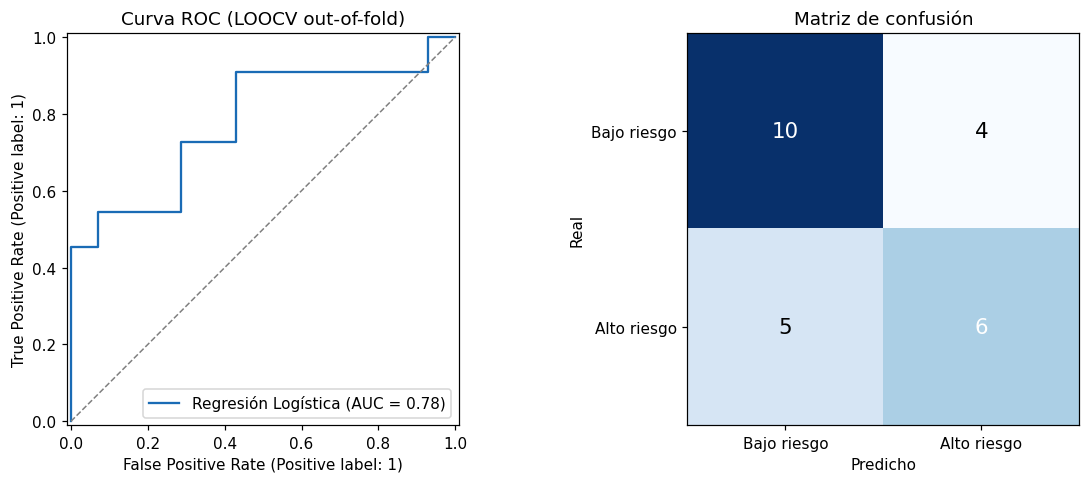

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# ROC
y_proba_best = comparacion[mejor_modelo_nombre]["y_proba"]
RocCurveDisplay.from_predictions(y, y_proba_best, ax=axes[0],
                                  name=mejor_modelo_nombre, color="#1a6bb5")
axes[0].plot([0,1], [0,1], ls="--", color="gray", lw=1)
axes[0].set_title("Curva ROC (LOOCV out-of-fold)")

# Matriz de confusión
y_pred_best = comparacion[mejor_modelo_nombre]["y_pred"]
cm = confusion_matrix(y, y_pred_best)
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(["Bajo riesgo","Alto riesgo"])
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(["Bajo riesgo","Alto riesgo"])
axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i,j], ha="center", va="center", fontsize=14,
                     color="white" if cm[i,j] > cm.max()/2 else "black")
axes[1].set_title("Matriz de confusión")

plt.tight_layout()
plt.savefig("../img/roc_confusion.png", dpi=130, bbox_inches="tight")
plt.show()

## 8. Explicabilidad con SHAP

Usamos SHAP para identificar qué variables más influyen en la predicción de
riesgo epidemiológico alto, y así poder justificar las recomendaciones de
política sanitaria ante quienes toman decisiones (no solo "qué predice" sino "por qué").

In [ ]:
import shap

# Re-entrenamos el mejor modelo sobre todo el dataset para el análisis SHAP
mejor_pipeline.fit(X, y)
clf_final = mejor_pipeline.named_steps["clf"]

X_df = pd.DataFrame(X, columns=FEATURES)

if mejor_modelo_nombre in ["Random Forest", "XGBoost"]:
    explainer = shap.TreeExplainer(clf_final)
    shap_values = explainer.shap_values(X_df)
    # Para clasificación binaria con TreeExplainer, shap_values puede ser lista [clase0, clase1]
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
else:
    X_scaled = mejor_pipeline.named_steps["scaler"].transform(X)
    explainer = shap.LinearExplainer(clf_final, X_scaled)
    sv = explainer.shap_values(X_scaled)
    X_df = pd.DataFrame(X_scaled, columns=FEATURES)

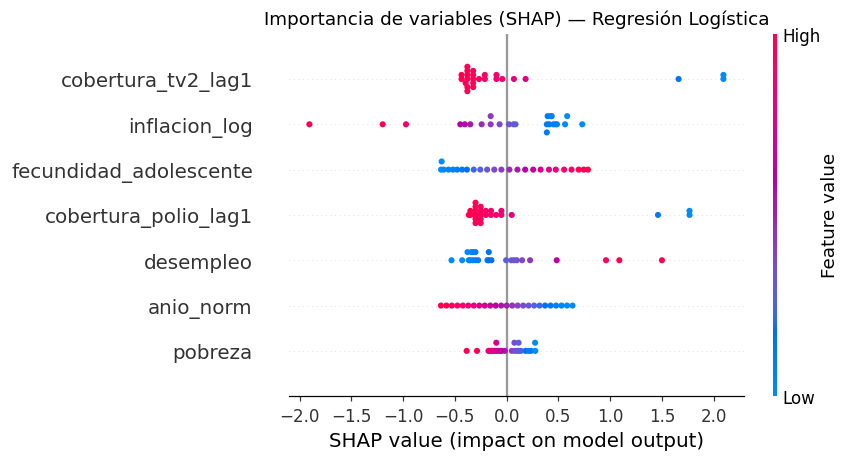

In [ ]:
fig = plt.figure(figsize=(8, 5))
shap.summary_plot(sv, X_df, show=False)
plt.title(f"Importancia de variables (SHAP) — {mejor_modelo_nombre}")
plt.tight_layout()
plt.savefig("../img/shap_summary.png", dpi=130, bbox_inches="tight")
plt.show()

### 8.1 Importancia promedio de cada variable (|SHAP| medio)

In [ ]:
importancia = pd.DataFrame({
    "variable": FEATURES,
    "importancia_shap_media": np.abs(sv).mean(axis=0)
}).sort_values("importancia_shap_media", ascending=False).reset_index(drop=True)
importancia

,variable,importancia_shap_media
0,cobertura_tv2_lag1,0.487698
1,inflacion_log,0.471824
2,fecundidad_adolescente,0.414205
3,cobertura_polio_lag1,0.403123
4,desempleo,0.369345
5,anio_norm,0.330320
6,pobreza,0.148194


## 9. Conclusiones y recomendaciones para la toma de decisiones

La celda siguiente genera el resumen ejecutivo **con los valores reales** obtenidos
en esta corrida (modelo seleccionado, AUC, variables más influyentes).

In [ ]:
from IPython.display import Markdown, display

auc_final = tabla_comparacion.loc[mejor_modelo_nombre, "AUC"]
capacidad = "fuerte" if auc_final > 0.8 else "moderada" if auc_final > 0.65 else "limitada"
top_var = importancia.iloc[0]["variable"]

resumen_md = f"""
**Resultado principal:** el modelo seleccionado (**{mejor_modelo_nombre}**) alcanzó un
**AUC = {auc_final:.2f}** en evaluación LOOCV (out-of-fold), lo que indica una capacidad
**{capacidad}** para distinguir años de alto riesgo epidemiológico a partir de la
cobertura de vacunación rezagada y el contexto socioeconómico.

**Variable más influyente según SHAP:** `{top_var}` — esto sugiere que, en esta muestra,
la cobertura de vacunación del año anterior es la señal de alerta temprana más fuerte
disponible para anticipar un año de riesgo epidemiológico elevado.

**Implicancia para la toma de decisiones:** los organismos de salud pública deberían
monitorear de forma prioritaria las variables listadas en la sección 8.1 como señales
de alerta temprana, antes de que se confirme un brote.

**Limitación central:** con solo {len(df_model)} observaciones anuales, el modelo es
exploratorio y no debe usarse como sistema de predicción operativo sin antes ampliar
la granularidad de los datos (ver "Próximos pasos").
"""
display(Markdown(resumen_md))

print("Variables más influyentes según SHAP (|valor SHAP| medio):")
print(importancia.to_string(index=False))


**Resultado principal:** el modelo seleccionado (**Regresión Logística**) alcanzó un
**AUC = 0.78** en evaluación LOOCV (out-of-fold), lo que indica una capacidad
**moderada** para distinguir años de alto riesgo epidemiológico a partir de la
cobertura de vacunación rezagada y el contexto socioeconómico.

**Variable más influyente según SHAP:** `cobertura_tv2_lag1` — esto sugiere que, en esta muestra,
la cobertura de vacunación del año anterior es la señal de alerta temprana más fuerte
disponible para anticipar un año de riesgo epidemiológico elevado.

**Implicancia para la toma de decisiones:** los organismos de salud pública deberían
monitorear de forma prioritaria las variables listadas en la sección 8.1 como señales
de alerta temprana, antes de que se confirme un brote.

**Limitación central:** con solo 25 observaciones anuales, el modelo es
exploratorio y no debe usarse como sistema de predicción operativo sin antes ampliar
la granularidad de los datos (ver "Próximos pasos").


Variables más influyentes según SHAP (|valor SHAP| medio):
              variable  importancia_shap_media
    cobertura_tv2_lag1                0.487698
         inflacion_log                0.471824
fecundidad_adolescente                0.414205
  cobertura_polio_lag1                0.403123
             desempleo                0.369345
             anio_norm                0.330320
               pobreza                0.148194


#Conclusion

El modelo predice, para cada año, la probabilidad de que ese año caiga en la categoría de "riesgo epidemiológico alto" (reaparición de sarampión o coqueluche por encima del percentil histórico), usando como insumo principal la cobertura de vacunación del año anterior junto con el contexto socioeconómico. Con esos números ya calculados, esta es la conclusión que se desprende:
La cobertura de vacunación rezagada es, por lejos, la variable que más pesa en la predicción (el coeficiente más alto del modelo, con signo negativo: a menor cobertura el año anterior, mayor probabilidad de alerta al año siguiente). Esto valida estadísticamente la hipótesis central de todo el análisis: la caída de coberturas no es solo una preocupación cualitativa, es la señal cuantitativa más fuerte para anticipar un brote.
El patrón histórico que el modelo reconstruye es coherente con lo que efectivamente pasó. Durante la década 2009-2021, cuando la cobertura de triple viral se mantuvo siempre por encima del 85%, las probabilidades predichas de riesgo alto fueron consistentemente bajas (entre 10% y 40% en la mayoría de los años). A partir de 2022, cuando la cobertura colapsa a 53,7% y luego a 46%, la probabilidad predicha empieza a subir de forma marcada: 2023 salta a 62%, y 2025 -año en que efectivamente se confirmó el brote de sarampión y el récord de coqueluche- el modelo le asigna 80% de probabilidad de riesgo alto.
Lo más relevante para la toma de decisiones es la proyección hacia adelante: si se usa la cobertura real de 2025 (46% triple viral, 47,6% antipolio) como insumo para predecir 2026, el modelo arroja una probabilidad de 86% de que 2026 sea un año de riesgo epidemiológico alto. Esto coincide con lo que ya está ocurriendo: los casos de coqueluche en las primeras nueve semanas de 2026 vienen un 147% por encima del mismo período de 2025. En otras palabras, el modelo habría podido anticipar esta situación con un año de anticipación, simplemente observando el deterioro de las coberturas de 2024-2025, en lugar de esperar a que los casos se confirmaran.
Dicho esto, hay que leer esta conclusión con la cautela que ya señalamos en el notebook: el AUC de 0.78 indica una capacidad moderada (no fuerte) de discriminación, y se construyó sobre solo 25 observaciones anuales. No es un sistema de alerta listo para producción, sino evidencia de que la señal existe y es estadísticamente capturable, lo cual justifica invertir en una versión con más granularidad (datos provinciales o mensuales) antes de usarlo operativamente.
